In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

# 将预训练模型缓存放在D盘
torch_cache = Path(
    "models/torch_cache"
).resolve()

torch_cache.mkdir(
    parents=True,
    exist_ok=True
)

os.environ["TORCH_HOME"] = str(torch_cache)

# 固定随机种子
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# 读取与Scratch CNN完全相同的数据划分
metadata = pd.read_csv(
    "data/metadata/ravdess_prepared.csv"
)

train_df = metadata[
    metadata["split"] == "train"
].reset_index(drop=True)

validation_df = metadata[
    metadata["split"] == "validation"
].reset_index(drop=True)

test_df = metadata[
    metadata["split"] == "test"
].reset_index(drop=True)

emotion_names = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised",
]

print("Device:", device)
print("Torch cache:", torch_cache)
print("Train samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))
print("Number of classes:", len(emotion_names))

Device: cuda
Torch cache: D:\Robotique\Appentisage\CNN_Documents\models\torch_cache
Train samples: 960
Validation samples: 240
Test samples: 240
Number of classes: 8


In [2]:
class TransferDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augment = augment

        # ImageNet预训练模型使用的均值和标准差
        self.image_mean = torch.tensor(
            [0.485, 0.456, 0.406],
            dtype=torch.float32
        ).view(3, 1, 1)

        self.image_std = torch.tensor(
            [0.229, 0.224, 0.225],
            dtype=torch.float32
        ).view(3, 1, 1)

    def __len__(self):
        return len(self.dataframe)

    def apply_spec_augment(self, feature):
        feature = feature.copy()

        frequency_size, time_size = feature.shape

        # 遮挡部分频率
        frequency_width = random.randint(1, 8)
        frequency_start = random.randint(
            0,
            frequency_size - frequency_width
        )

        feature[
            frequency_start:
            frequency_start + frequency_width,
            :
        ] = 0.0

        # 遮挡部分时间
        time_width = random.randint(1, 12)
        time_start = random.randint(
            0,
            time_size - time_width
        )

        feature[
            :,
            time_start:
            time_start + time_width
        ] = 0.0

        return feature

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        feature = np.load(
            row["feature_path"]
        ).astype(np.float32)

        # 只增强训练集
        if self.augment:
            feature = self.apply_spec_augment(feature)

        # (128, 126) → (1, 128, 126)
        feature = torch.from_numpy(
            feature
        ).unsqueeze(0)

        # 单通道复制为RGB三通道
        # (1, 128, 126) → (3, 128, 126)
        feature = feature.repeat(3, 1, 1)

        # 调整为ResNet标准输入尺寸
        # (3, 128, 126) → (3, 224, 224)
        feature = F.interpolate(
            feature.unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        # 按ImageNet规则标准化
        feature = (
            feature - self.image_mean
        ) / self.image_std

        label = torch.tensor(
            int(row["label_id"]),
            dtype=torch.long
        )

        return feature, label

In [3]:
train_dataset = TransferDataset(
    train_df,
    augment=True
)

validation_dataset = TransferDataset(
    validation_df,
    augment=False
)

test_dataset = TransferDataset(
    test_df,
    augment=False
)

BATCH_SIZE = 16

data_generator = torch.Generator()
data_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=data_generator
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

batch_features, batch_labels = next(
    iter(train_loader)
)

print("Feature batch shape:", batch_features.shape)
print("Label batch shape:", batch_labels.shape)
print("Feature minimum:", batch_features.min().item())
print("Feature maximum:", batch_features.max().item())
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Feature batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Feature minimum: -2.1179039478302
Feature maximum: 2.616696357727051
Training batches: 60
Validation batches: 15
Test batches: 15


In [5]:
# 下载并载入ImageNet预训练权重
weights = ResNet18_Weights.DEFAULT

transfer_model = resnet18(
    weights=weights
)

# 冻结全部预训练参数
for parameter in transfer_model.parameters():
    parameter.requires_grad = False

# ResNet18原分类层接收512个特征
number_of_features = transfer_model.fc.in_features

# 将原来的1000类图像分类器
# 替换成我们的8类情绪分类器
transfer_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(
        number_of_features,
        len(emotion_names)
    )
)

transfer_model = transfer_model.to(device)

In [6]:
total_parameters = sum(
    parameter.numel()
    for parameter in transfer_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in transfer_model.parameters()
    if parameter.requires_grad
)

frozen_parameters = (
    total_parameters - trainable_parameters
)

# 用一个样本检查模型输出
check_feature = batch_features[:1].to(device)

transfer_model.eval()

with torch.no_grad():
    check_output = transfer_model(check_feature)

transfer_model.train()

print("Input shape:", check_feature.shape)
print("Output shape:", check_output.shape)
print("Total parameters:", total_parameters)
print("Frozen parameters:", frozen_parameters)
print("Trainable parameters:", trainable_parameters)
print("Final classifier:")
print(transfer_model.fc)

Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 8])
Total parameters: 11180616
Frozen parameters: 11176512
Trainable parameters: 4104
Final classifier:
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=8, bias=True)
)


In [7]:
# 计算类别权重
class_counts = (
    train_df
    .groupby("label_id")
    .size()
    .reindex(range(len(emotion_names)))
)

class_weights = (
    len(train_df) /
    (len(emotion_names) * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# 第一阶段只优化当前可训练的分类层
stage1_optimizer = torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        transfer_model.parameters()
    ),
    lr=0.001,
    weight_decay=0.0001
)

In [8]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    # 数据较少，保持预训练BatchNorm统计量固定
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for features, labels in data_loader:
        features = features.to(
            device,
            non_blocking=True
        )
        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        outputs = model(features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (
            outputs.argmax(dim=1) == labels
        ).sum().item()
        total_samples += batch_size

    return (
        total_loss / total_samples,
        100.0 * total_correct / total_samples
    )

In [9]:
@torch.no_grad()
def evaluate(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for features, labels in data_loader:
        features = features.to(
            device,
            non_blocking=True
        )
        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(features)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (
            outputs.argmax(dim=1) == labels
        ).sum().item()
        total_samples += batch_size

    return (
        total_loss / total_samples,
        100.0 * total_correct / total_samples
    )

In [10]:
stage1_model_path = Path(
    "models/resnet18_stage1_best.pt"
)

stage1_history = []
best_stage1_loss = float("inf")

for epoch in range(1, 6):
    train_loss, train_accuracy = train_one_epoch(
        transfer_model,
        train_loader,
        criterion,
        stage1_optimizer,
        device
    )

    validation_loss, validation_accuracy = evaluate(
        transfer_model,
        validation_loader,
        criterion,
        device
    )

    stage1_history.append({
        "stage": 1,
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "validation_loss": validation_loss,
        "validation_accuracy": validation_accuracy,
        "learning_rate": 0.001
    })

    print(
        f"Stage 1 — Epoch {epoch}/5 | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:6.2f}% | "
        f"Val loss: {validation_loss:.4f} | "
        f"Val acc: {validation_accuracy:6.2f}%"
    )

    if validation_loss < best_stage1_loss:
        best_stage1_loss = validation_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict":
                transfer_model.state_dict(),
            "validation_loss": validation_loss,
            "validation_accuracy":
                validation_accuracy,
            "emotion_names": emotion_names
        }, stage1_model_path)

        print("  → Best Stage 1 model saved")

Stage 1 — Epoch 1/5 | Train loss: 2.1765 | Train acc:  15.21% | Val loss: 1.9365 | Val acc:  28.75%
  → Best Stage 1 model saved
Stage 1 — Epoch 2/5 | Train loss: 1.9573 | Train acc:  24.90% | Val loss: 1.8226 | Val acc:  28.75%
  → Best Stage 1 model saved
Stage 1 — Epoch 3/5 | Train loss: 1.8411 | Train acc:  28.65% | Val loss: 1.7263 | Val acc:  38.33%
  → Best Stage 1 model saved
Stage 1 — Epoch 4/5 | Train loss: 1.7659 | Train acc:  32.92% | Val loss: 1.6913 | Val acc:  35.42%
  → Best Stage 1 model saved
Stage 1 — Epoch 5/5 | Train loss: 1.7369 | Train acc:  36.46% | Val loss: 1.6822 | Val acc:  34.58%
  → Best Stage 1 model saved


In [19]:
stage1_checkpoint = torch.load(
    stage1_model_path,
    map_location=device,
    weights_only=False
)

transfer_model.load_state_dict(
    stage1_checkpoint["model_state_dict"]
)

print("\nBest Stage 1 epoch:",
      stage1_checkpoint["epoch"])

print(
    "Best Stage 1 validation accuracy:",
    round(
        stage1_checkpoint[
            "validation_accuracy"
        ],
        2
    ),
    "%"
)


Best Stage 1 epoch: 5
Best Stage 1 validation accuracy: 34.58 %


In [20]:
# 解冻ResNet18最后一个卷积阶段
for parameter in transfer_model.layer4.parameters():
    parameter.requires_grad = True

# 分类层继续训练
for parameter in transfer_model.fc.parameters():
    parameter.requires_grad = True

trainable_parameters = sum(
    parameter.numel()
    for parameter in transfer_model.parameters()
    if parameter.requires_grad
)

print("Trainable parameters in Stage 2:",
      trainable_parameters)

Trainable parameters in Stage 2: 8397832


In [21]:
# 深层卷积使用较小学习率，避免破坏预训练知识
# 新分类层使用稍大的学习率
stage2_optimizer = torch.optim.AdamW(
    [
        {
            "params":
                transfer_model.layer4.parameters(),
            "lr": 0.0001
        },
        {
            "params":
                transfer_model.fc.parameters(),
            "lr": 0.0005
        }
    ],
    weight_decay=0.0001
)

stage2_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        stage2_optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )
)

In [22]:
MAX_STAGE2_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6

final_model_path = Path(
    "models/resnet18_transfer_best.pt"
)

history_path = Path(
    "results/metrics/"
    "resnet18_transfer_training_history.csv"
)

history = stage1_history.copy()

# 当前起点是第一阶段的最佳模型
best_validation_loss = (
    stage1_checkpoint["validation_loss"]
)

best_validation_accuracy = (
    stage1_checkpoint["validation_accuracy"]
)

best_stage = 1
best_stage_epoch = stage1_checkpoint["epoch"]
epochs_without_improvement = 0

# 先将第一阶段最佳模型保存为最终模型候选
torch.save({
    "stage": 1,
    "stage_epoch": best_stage_epoch,
    "model_state_dict":
        transfer_model.state_dict(),
    "validation_loss": best_validation_loss,
    "validation_accuracy":
        best_validation_accuracy,
    "emotion_names": emotion_names
}, final_model_path)

for epoch in range(1, MAX_STAGE2_EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        transfer_model,
        train_loader,
        criterion,
        stage2_optimizer,
        device
    )

    validation_loss, validation_accuracy = evaluate(
        transfer_model,
        validation_loader,
        criterion,
        device
    )

    stage2_scheduler.step(validation_loss)

    layer4_lr = (
        stage2_optimizer.param_groups[0]["lr"]
    )
    classifier_lr = (
        stage2_optimizer.param_groups[1]["lr"]
    )

    history.append({
        "stage": 2,
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "validation_loss": validation_loss,
        "validation_accuracy": validation_accuracy,
        "learning_rate": classifier_lr
    })

    print(
        f"Stage 2 — Epoch "
        f"{epoch:02d}/{MAX_STAGE2_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:6.2f}% | "
        f"Val loss: {validation_loss:.4f} | "
        f"Val acc: {validation_accuracy:6.2f}% | "
        f"Layer4 LR: {layer4_lr:.6f} | "
        f"FC LR: {classifier_lr:.6f}"
    )

    if validation_loss < best_validation_loss - 1e-4:
        best_validation_loss = validation_loss
        best_validation_accuracy = validation_accuracy
        best_stage = 2
        best_stage_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "stage": 2,
            "stage_epoch": epoch,
            "model_state_dict":
                transfer_model.state_dict(),
            "validation_loss": validation_loss,
            "validation_accuracy":
                validation_accuracy,
            "emotion_names": emotion_names
        }, final_model_path)

        print("  → Best transfer model saved")

    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping: validation loss "
            "did not improve for "
            f"{EARLY_STOPPING_PATIENCE} epochs."
        )
        break

Stage 2 — Epoch 01/25 | Train loss: 1.7554 | Train acc:  35.31% | Val loss: 1.5886 | Val acc:  38.75% | Layer4 LR: 0.000100 | FC LR: 0.000500
  → Best transfer model saved
Stage 2 — Epoch 02/25 | Train loss: 1.5135 | Train acc:  44.48% | Val loss: 1.7233 | Val acc:  31.25% | Layer4 LR: 0.000100 | FC LR: 0.000500
Stage 2 — Epoch 03/25 | Train loss: 1.3688 | Train acc:  48.33% | Val loss: 1.3904 | Val acc:  45.83% | Layer4 LR: 0.000100 | FC LR: 0.000500
  → Best transfer model saved
Stage 2 — Epoch 04/25 | Train loss: 1.2546 | Train acc:  53.33% | Val loss: 1.4813 | Val acc:  47.08% | Layer4 LR: 0.000100 | FC LR: 0.000500
Stage 2 — Epoch 05/25 | Train loss: 1.1412 | Train acc:  57.50% | Val loss: 1.4760 | Val acc:  49.17% | Layer4 LR: 0.000100 | FC LR: 0.000500
Stage 2 — Epoch 06/25 | Train loss: 1.0841 | Train acc:  58.65% | Val loss: 1.4142 | Val acc:  56.25% | Layer4 LR: 0.000050 | FC LR: 0.000250
Stage 2 — Epoch 07/25 | Train loss: 0.9162 | Train acc:  64.90% | Val loss: 1.3463 | Val

In [23]:
history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

best_checkpoint = torch.load(
    final_model_path,
    map_location=device,
    weights_only=False
)

transfer_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

print("\nTraining finished.")
print("Best stage:", best_checkpoint["stage"])
print(
    "Best stage epoch:",
    best_checkpoint["stage_epoch"]
)
print(
    "Best validation loss:",
    round(
        best_checkpoint["validation_loss"],
        4
    )
)
print(
    "Best validation accuracy:",
    round(
        best_checkpoint[
            "validation_accuracy"
        ],
        2
    ),
    "%"
)
print("Model saved to:",
      final_model_path.resolve())


Training finished.
Best stage: 2
Best stage epoch: 9
Best validation loss: 1.2603
Best validation accuracy: 61.67 %
Model saved to: D:\Robotique\Appentisage\CNN_Documents\models\resnet18_transfer_best.pt


CSV columns: ['stage', 'epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate']


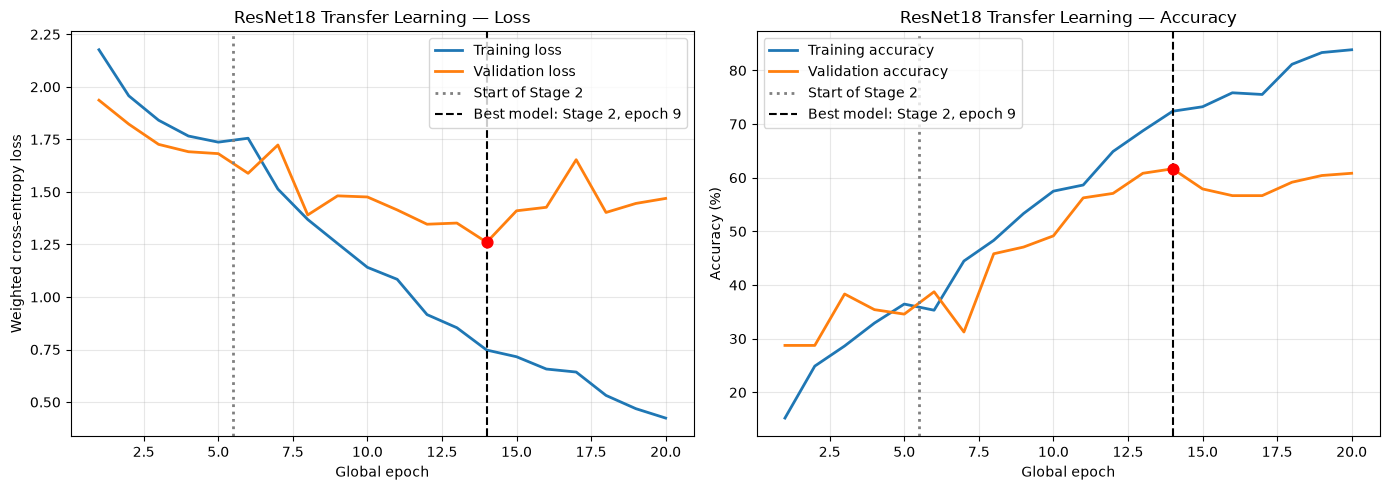


Transfer-learning training summary
----------------------------------
Best stage: 2
Best stage epoch: 9
Best global epoch: 14
Best validation loss: 1.2603
Best validation accuracy: 61.67 %
Figure saved to: D:\Robotique\Appentisage\CNN_Documents\results\figures\resnet18_transfer_training_curves.png


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 读取训练历史
history_path = Path(
    "results/metrics/resnet18_transfer_training_history.csv"
)

history_df = pd.read_csv(history_path)

# 统一列名，解决 validation_accuracy / val_accuracy 的命名差异
history_df = history_df.rename(columns={
    "validation_loss": "val_loss",
    "validation_accuracy": "val_accuracy",
    "train_acc": "train_accuracy",
    "val_acc": "val_accuracy"
})

print("CSV columns:", history_df.columns.tolist())

# 检查绘图需要的列是否存在
required_columns = [
    "stage",
    "epoch",
    "train_loss",
    "val_loss",
    "train_accuracy",
    "val_accuracy"
]

missing_columns = [
    column for column in required_columns
    if column not in history_df.columns
]

if missing_columns:
    raise ValueError(
        f"CSV 中缺少以下列：{missing_columns}\n"
        f"当前列名为：{history_df.columns.tolist()}"
    )

# 创建连续的总 epoch 编号
history_df["global_epoch"] = range(
    1,
    len(history_df) + 1
)

# 将 Stage 转换成数字，兼容 1、2、Stage 1、Stage 2 等写法
history_df["stage_number"] = (
    history_df["stage"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

# 获取准确率
train_acc = history_df["train_accuracy"].astype(float).copy()
val_acc = history_df["val_accuracy"].astype(float).copy()

# 如果准确率保存为 0~1，则转换为百分数
if max(train_acc.max(), val_acc.max()) <= 1.0:
    train_acc *= 100
    val_acc *= 100

# 根据最低验证损失确定最终最佳模型
best_index = history_df["val_loss"].astype(float).idxmin()

best_global_epoch = int(
    history_df.loc[best_index, "global_epoch"]
)

best_stage = int(
    history_df.loc[best_index, "stage_number"]
)

best_stage_epoch = int(
    history_df.loc[best_index, "epoch"]
)

best_val_loss = float(
    history_df.loc[best_index, "val_loss"]
)

best_val_accuracy = float(
    val_acc.loc[best_index]
)

# Stage 1 的训练轮数，用于画阶段分界线
stage1_count = int(
    (history_df["stage_number"] == 1).sum()
)

# 创建图像
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# =========================
# 左图：损失曲线
# =========================
axes[0].plot(
    history_df["global_epoch"],
    history_df["train_loss"],
    color="tab:blue",
    linewidth=2,
    label="Training loss"
)

axes[0].plot(
    history_df["global_epoch"],
    history_df["val_loss"],
    color="tab:orange",
    linewidth=2,
    label="Validation loss"
)

axes[0].axvline(
    stage1_count + 0.5,
    color="gray",
    linestyle=":",
    linewidth=2,
    label="Start of Stage 2"
)

axes[0].axvline(
    best_global_epoch,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Best model: Stage {best_stage}, epoch {best_stage_epoch}"
)

axes[0].scatter(
    best_global_epoch,
    best_val_loss,
    color="red",
    s=60,
    zorder=5
)

axes[0].set_title(
    "ResNet18 Transfer Learning — Loss"
)
axes[0].set_xlabel("Global epoch")
axes[0].set_ylabel("Weighted cross-entropy loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

# =========================
# 右图：准确率曲线
# =========================
axes[1].plot(
    history_df["global_epoch"],
    train_acc,
    color="tab:blue",
    linewidth=2,
    label="Training accuracy"
)

axes[1].plot(
    history_df["global_epoch"],
    val_acc,
    color="tab:orange",
    linewidth=2,
    label="Validation accuracy"
)

axes[1].axvline(
    stage1_count + 0.5,
    color="gray",
    linestyle=":",
    linewidth=2,
    label="Start of Stage 2"
)

axes[1].axvline(
    best_global_epoch,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Best model: Stage {best_stage}, epoch {best_stage_epoch}"
)

axes[1].scatter(
    best_global_epoch,
    best_val_accuracy,
    color="red",
    s=60,
    zorder=5
)

axes[1].set_title(
    "ResNet18 Transfer Learning — Accuracy"
)
axes[1].set_xlabel("Global epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

# 保存图片
figure_path = Path(
    "results/figures/resnet18_transfer_training_curves.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 输出最佳结果
print("\nTransfer-learning training summary")
print("----------------------------------")
print("Best stage:", best_stage)
print("Best stage epoch:", best_stage_epoch)
print("Best global epoch:", best_global_epoch)
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_accuracy:.2f} %")
print("Figure saved to:", figure_path.resolve())

Loaded model: D:\Robotique\Appentisage\CNN_Documents\models\resnet18_transfer_best.pt
Evaluation device: cuda

ResNet18 transfer-learning final test results
---------------------------------------------
Test samples: 240
Test loss: 1.5883
Test accuracy: 56.67 %
Macro F1: 0.5457
Weighted F1: 0.5413


,precision,recall,f1-score,support
neutral,0.5500,0.6875,0.6111,16.0000
calm,0.4906,0.8125,0.6118,32.0000
happy,0.3750,0.2812,0.3214,32.0000
sad,0.4138,0.3750,0.3934,32.0000
angry,0.8182,0.5625,0.6667,32.0000
fearful,0.6667,0.1875,0.2927,32.0000
disgust,0.5854,0.7500,0.6575,32.0000
surprised,0.7143,0.9375,0.8108,32.0000
accuracy,0.5667,0.5667,0.5667,0.5667
macro avg,0.5767,0.5742,0.5457,240.0000


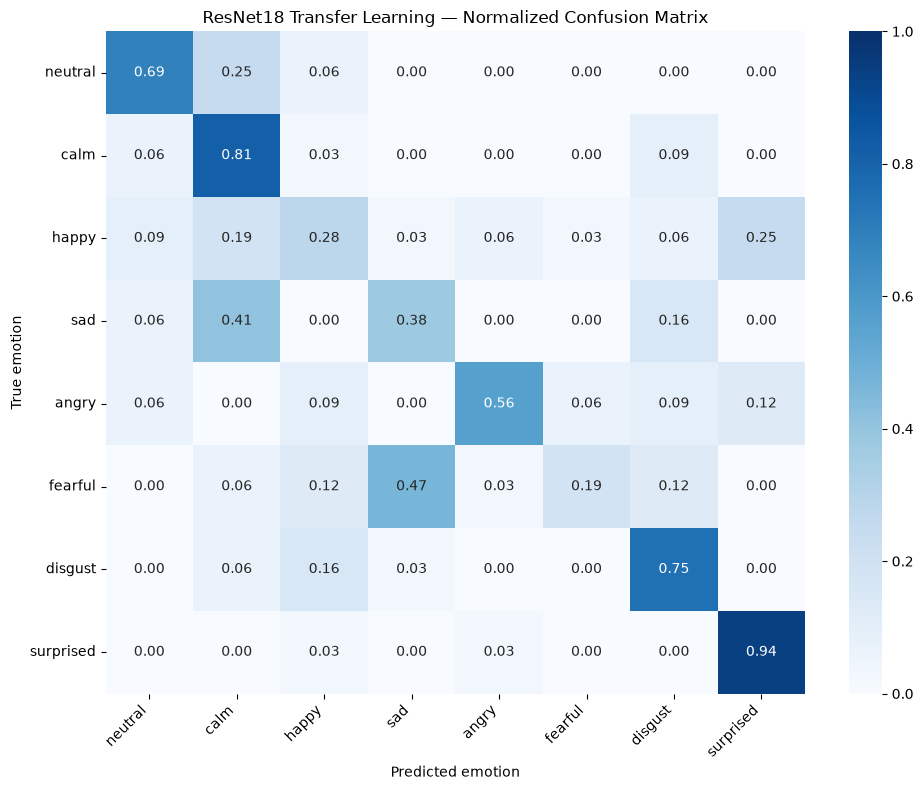


Report saved to: D:\Robotique\Appentisage\CNN_Documents\results\metrics\resnet18_transfer_classification_report.csv
Summary saved to: D:\Robotique\Appentisage\CNN_Documents\results\metrics\resnet18_transfer_test_summary.csv
Confusion matrix saved to: D:\Robotique\Appentisage\CNN_Documents\results\figures\resnet18_transfer_confusion_matrix.png


In [27]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 八种情绪及其标签顺序
emotion_names = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised"
]

# =========================
# 1. 加载最佳迁移学习模型
# =========================
checkpoint_path = Path(
    "models/resnet18_transfer_best.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

# 兼容不同的模型保存格式
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

transfer_model.load_state_dict(state_dict)
transfer_model = transfer_model.to(device)
transfer_model.eval()

print("Loaded model:", checkpoint_path.resolve())
print("Evaluation device:", device)

# =========================
# 2. 在测试集上推理
# =========================
test_loss_sum = 0.0
test_sample_count = 0

all_true_labels = []
all_predicted_labels = []
all_probabilities = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(
            device,
            non_blocking=True
        )
        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = transfer_model(features)
        loss = criterion(outputs, labels)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = outputs.argmax(dim=1)

        batch_size = labels.size(0)

        test_loss_sum += loss.item() * batch_size
        test_sample_count += batch_size

        all_true_labels.extend(
            labels.cpu().numpy()
        )
        all_predicted_labels.extend(
            predictions.cpu().numpy()
        )
        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

all_true_labels = np.array(all_true_labels)
all_predicted_labels = np.array(all_predicted_labels)
all_probabilities = np.array(all_probabilities)

test_loss = test_loss_sum / test_sample_count

# =========================
# 3. 计算最终指标
# =========================
test_accuracy = accuracy_score(
    all_true_labels,
    all_predicted_labels
)

macro_f1 = f1_score(
    all_true_labels,
    all_predicted_labels,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    all_true_labels,
    all_predicted_labels,
    average="weighted",
    zero_division=0
)

print("\nResNet18 transfer-learning final test results")
print("---------------------------------------------")
print(f"Test samples: {test_sample_count}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f} %")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

# =========================
# 4. 分类报告
# =========================
report_dict = classification_report(
    all_true_labels,
    all_predicted_labels,
    labels=list(range(len(emotion_names))),
    target_names=emotion_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

display(report_df.round(4))

report_path = Path(
    "results/metrics/resnet18_transfer_classification_report.csv"
)

report_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

report_df.to_csv(
    report_path,
    index=True
)

# =========================
# 5. 保存测试结果摘要
# =========================
summary_df = pd.DataFrame({
    "model": ["ResNet18 transfer learning"],
    "test_loss": [test_loss],
    "test_accuracy": [test_accuracy],
    "macro_f1": [macro_f1],
    "weighted_f1": [weighted_f1],
    "test_samples": [test_sample_count]
})

summary_path = Path(
    "results/metrics/resnet18_transfer_test_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

# =========================
# 6. 计算归一化混淆矩阵
# =========================
confusion_normalized = confusion_matrix(
    all_true_labels,
    all_predicted_labels,
    labels=list(range(len(emotion_names))),
    normalize="true"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    confusion_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title(
    "ResNet18 Transfer Learning — Normalized Confusion Matrix"
)
plt.xlabel("Predicted emotion")
plt.ylabel("True emotion")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

confusion_path = Path(
    "results/figures/resnet18_transfer_confusion_matrix.png"
)

confusion_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nReport saved to:", report_path.resolve())
print("Summary saved to:", summary_path.resolve())
print("Confusion matrix saved to:", confusion_path.resolve())

,Model,Test loss,Test accuracy,Macro F1,Weighted F1
0,Scratch CNN,1.3101,0.5083,0.4667,0.4671
1,ResNet18 Transfer Learning,1.5883,0.5667,0.5457,0.5413


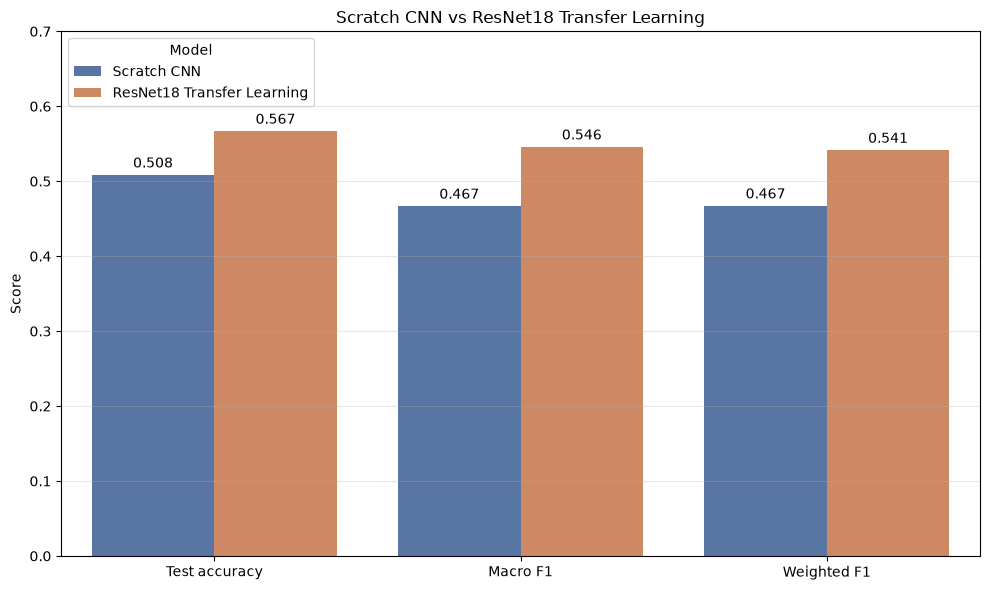

Transfer-learning improvement
-----------------------------
Test accuracy: +5.84 percentage points
Macro F1: +0.0790
Weighted F1: +0.0742
Table saved to: D:\Robotique\Appentisage\CNN_Documents\results\metrics\model_comparison.csv
Figure saved to: D:\Robotique\Appentisage\CNN_Documents\results\figures\model_comparison.png


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 两个模型的最终测试结果
comparison_df = pd.DataFrame({
    "Model": [
        "Scratch CNN",
        "ResNet18 Transfer Learning"
    ],
    "Test loss": [
        1.3101,
        1.5883
    ],
    "Test accuracy": [
        0.5083,
        0.5667
    ],
    "Macro F1": [
        0.4667,
        0.5457
    ],
    "Weighted F1": [
        0.4671,
        0.5413
    ]
})

# 保存数值结果
comparison_path = Path(
    "results/metrics/model_comparison.csv"
)

comparison_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

display(comparison_df.round(4))

# 转换为长表，用于绘图
plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=[
        "Test accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    var_name="Metric",
    value_name="Score"
)

# 绘制对比图
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#4C72B0", "#DD8452"]
)

plt.title(
    "Scratch CNN vs ResNet18 Transfer Learning"
)
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 0.7)
plt.grid(
    axis="y",
    alpha=0.3
)

# 在柱形上标注数值
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.legend(
    title="Model",
    loc="upper left"
)
plt.tight_layout()

comparison_figure_path = Path(
    "results/figures/model_comparison.png"
)

comparison_figure_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 输出提高幅度
accuracy_improvement = (
    comparison_df.loc[1, "Test accuracy"]
    - comparison_df.loc[0, "Test accuracy"]
)

macro_f1_improvement = (
    comparison_df.loc[1, "Macro F1"]
    - comparison_df.loc[0, "Macro F1"]
)

weighted_f1_improvement = (
    comparison_df.loc[1, "Weighted F1"]
    - comparison_df.loc[0, "Weighted F1"]
)

print("Transfer-learning improvement")
print("-----------------------------")
print(
    f"Test accuracy: "
    f"+{accuracy_improvement * 100:.2f} percentage points"
)
print(
    f"Macro F1: "
    f"+{macro_f1_improvement:.4f}"
)
print(
    f"Weighted F1: "
    f"+{weighted_f1_improvement:.4f}"
)
print(
    "Table saved to:",
    comparison_path.resolve()
)
print(
    "Figure saved to:",
    comparison_figure_path.resolve()
)

In [29]:
%%writefile app/app.py

import io
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import streamlit as st
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18


# =========================================================
# 页面与项目路径
# =========================================================
st.set_page_config(
    page_title="Speech Emotion Recognition",
    page_icon="🎙️",
    layout="wide"
)

APP_DIR = Path(__file__).resolve().parent
PROJECT_ROOT = APP_DIR.parent
MODEL_PATH = PROJECT_ROOT / "models" / "resnet18_transfer_best.pt"


# =========================================================
# 与训练阶段完全相同的参数
# =========================================================
SAMPLE_RATE = 16000
FIXED_DURATION = 4.0
FIXED_SAMPLES = int(SAMPLE_RATE * FIXED_DURATION)

N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 128
FMIN = 20
FMAX = 8000
TOP_DB = 80

EMOTIONS = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised"
]

EMOTION_ICONS = {
    "neutral": "😐",
    "calm": "😌",
    "happy": "😊",
    "sad": "😢",
    "angry": "😠",
    "fearful": "😨",
    "disgust": "🤢",
    "surprised": "😲"
}

IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1)


# =========================================================
# 加载模型
# =========================================================
@st.cache_resource
def load_model():
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = resnet18(weights=None)

    input_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(input_features, len(EMOTIONS))
    )

    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=False
    )

    if (
        isinstance(checkpoint, dict)
        and "model_state_dict" in checkpoint
    ):
        state_dict = checkpoint["model_state_dict"]

    elif (
        isinstance(checkpoint, dict)
        and "state_dict" in checkpoint
    ):
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

    # 兼容可能由 DataParallel 保存的模型
    state_dict = {
        key.removeprefix("module."): value
        for key, value in state_dict.items()
    }

    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    return model, device


# =========================================================
# 读取音频
# =========================================================
def read_audio(audio_bytes):
    audio, original_sample_rate = sf.read(
        io.BytesIO(audio_bytes),
        dtype="float32",
        always_2d=False
    )

    # 双声道或多声道转为单声道
    if audio.ndim == 2:
        audio = np.mean(audio, axis=1)

    # 重新采样为 16 kHz
    if original_sample_rate != SAMPLE_RATE:
        audio = librosa.resample(
            audio,
            orig_sr=original_sample_rate,
            target_sr=SAMPLE_RATE
        )

    audio = np.asarray(
        audio,
        dtype=np.float32
    )

    if len(audio) == 0:
        raise ValueError("The audio file is empty.")

    return audio


# =========================================================
# 音频预处理
# =========================================================
def preprocess_audio(audio):
    original_duration = len(audio) / SAMPLE_RATE

    # 去除开头和结尾的静音
    trimmed_audio, _ = librosa.effects.trim(
        audio,
        top_db=30
    )

    if len(trimmed_audio) == 0:
        trimmed_audio = audio

    # 中心裁剪或补零到固定4秒
    if len(trimmed_audio) > FIXED_SAMPLES:
        start = (
            len(trimmed_audio) - FIXED_SAMPLES
        ) // 2

        fixed_audio = trimmed_audio[
            start:start + FIXED_SAMPLES
        ]

    else:
        total_padding = (
            FIXED_SAMPLES - len(trimmed_audio)
        )

        left_padding = total_padding // 2
        right_padding = total_padding - left_padding

        fixed_audio = np.pad(
            trimmed_audio,
            (left_padding, right_padding),
            mode="constant"
        )

    # 计算 Mel 频谱
    mel_spectrogram = librosa.feature.melspectrogram(
        y=fixed_audio,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    # 转为 dB
    log_mel_db = librosa.power_to_db(
        mel_spectrogram,
        ref=np.max,
        top_db=TOP_DB
    )

    # 从 [-80, 0] 归一化到 [0, 1]
    normalized_log_mel = (
        log_mel_db + TOP_DB
    ) / TOP_DB

    normalized_log_mel = np.clip(
        normalized_log_mel,
        0.0,
        1.0
    ).astype(np.float32)

    return (
        fixed_audio,
        log_mel_db,
        normalized_log_mel,
        original_duration
    )


# =========================================================
# 转换为 ResNet18 输入
# =========================================================
def create_model_input(normalized_log_mel, device):
    feature_tensor = torch.from_numpy(
        normalized_log_mel
    ).unsqueeze(0).unsqueeze(0)

    # 单通道复制为三通道
    feature_tensor = feature_tensor.repeat(
        1,
        3,
        1,
        1
    )

    # 调整为 ImageNet 模型输入尺寸
    feature_tensor = F.interpolate(
        feature_tensor,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    # ImageNet 标准化
    feature_tensor = (
        feature_tensor - IMAGENET_MEAN
    ) / IMAGENET_STD

    return feature_tensor.to(device)


# =========================================================
# 模型预测
# =========================================================
def predict_emotion(
    model,
    device,
    normalized_log_mel
):
    feature_tensor = create_model_input(
        normalized_log_mel,
        device
    )

    with torch.no_grad():
        logits = model(feature_tensor)

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0].cpu().numpy()

    predicted_index = int(
        np.argmax(probabilities)
    )

    predicted_emotion = EMOTIONS[
        predicted_index
    ]

    confidence = float(
        probabilities[predicted_index]
    )

    return (
        predicted_emotion,
        confidence,
        probabilities
    )


# =========================================================
# 网页界面
# =========================================================
st.title("🎙️ Speech Emotion Recognition")
st.write(
    "Record your voice or upload an audio file. "
    "The ResNet18 transfer-learning model predicts "
    "one of eight emotions."
)

st.info(
    "For the best result, speak one short sentence "
    "clearly for approximately 2–4 seconds."
)

if not MODEL_PATH.exists():
    st.error(
        f"Model file not found: {MODEL_PATH}"
    )
    st.stop()

try:
    model, device = load_model()

except Exception as error:
    st.error(
        f"Unable to load the model: {error}"
    )
    st.stop()

with st.sidebar:
    st.header("Model information")
    st.write("**Model:** ResNet18")
    st.write("**Method:** Transfer learning")
    st.write("**Dataset:** RAVDESS")
    st.write("**Test accuracy:** 56.67%")
    st.write("**Macro F1:** 0.5457")
    st.write(f"**Device:** {device}")

input_method = st.radio(
    "Choose the audio input method:",
    [
        "Record with microphone",
        "Upload an audio file"
    ],
    horizontal=True
)

audio_file = None

if input_method == "Record with microphone":
    audio_file = st.audio_input(
        "Record your voice"
    )

else:
    audio_file = st.file_uploader(
        "Upload a WAV, FLAC or OGG file",
        type=["wav", "flac", "ogg"]
    )

if audio_file is not None:
    audio_bytes = audio_file.getvalue()

    st.subheader("Audio preview")
    st.audio(audio_bytes)

    try:
        raw_audio = read_audio(audio_bytes)

        (
            fixed_audio,
            log_mel_db,
            normalized_log_mel,
            original_duration
        ) = preprocess_audio(raw_audio)

        (
            predicted_emotion,
            confidence,
            probabilities
        ) = predict_emotion(
            model,
            device,
            normalized_log_mel
        )

        st.subheader("Prediction")

        result_column, confidence_column = st.columns(2)

        with result_column:
            st.metric(
                "Predicted emotion",
                (
                    f"{EMOTION_ICONS[predicted_emotion]} "
                    f"{predicted_emotion.capitalize()}"
                )
            )

        with confidence_column:
            st.metric(
                "Model confidence",
                f"{confidence * 100:.2f}%"
            )

        if confidence < 0.40:
            st.warning(
                "The prediction confidence is low. "
                "Try recording again with clearer speech "
                "and less background noise."
            )

        st.subheader("Log-Mel spectrogram")

        figure, axis = plt.subplots(
            figsize=(11, 4)
        )

        spectrogram_image = librosa.display.specshow(
            log_mel_db,
            sr=SAMPLE_RATE,
            hop_length=HOP_LENGTH,
            x_axis="time",
            y_axis="mel",
            fmin=FMIN,
            fmax=FMAX,
            cmap="magma",
            ax=axis
        )

        axis.set_title(
            "Processed Log-Mel Spectrogram"
        )

        figure.colorbar(
            spectrogram_image,
            ax=axis,
            format="%+2.0f dB"
        )

        figure.tight_layout()
        st.pyplot(figure)
        plt.close(figure)

        st.subheader("Emotion probabilities")

        probability_df = pd.DataFrame({
            "Emotion": EMOTIONS,
            "Probability": probabilities
        }).sort_values(
            "Probability",
            ascending=False
        )

        probability_df["Probability (%)"] = (
            probability_df["Probability"] * 100
        )

        st.bar_chart(
            probability_df.set_index(
                "Emotion"
            )["Probability (%)"]
        )

        st.dataframe(
            probability_df[
                ["Emotion", "Probability (%)"]
            ].style.format({
                "Probability (%)": "{:.2f}%"
            }),
            use_container_width=True,
            hide_index=True
        )

        with st.expander(
            "Audio preprocessing information"
        ):
            st.write(
                f"Original duration: "
                f"{original_duration:.2f} seconds"
            )
            st.write(
                f"Model duration: "
                f"{FIXED_DURATION:.2f} seconds"
            )
            st.write(
                f"Sample rate: {SAMPLE_RATE} Hz"
            )
            st.write(
                f"Log-Mel shape: "
                f"{normalized_log_mel.shape}"
            )

    except Exception as error:
        st.error(
            f"Unable to process this audio file: {error}"
        )

else:
    st.caption(
        "No audio has been provided yet."
    )

Writing app/app.py


In [2]:
from pathlib import Path
from importlib.metadata import version

PROJECT_ROOT = Path(
    r"D:\Robotique\Appentisage\CNN_Documents"
)

# =====================================================
# 1. requirements.txt
# =====================================================
package_names = [
    "streamlit",
    "torch",
    "torchvision",
    "librosa",
    "soundfile",
    "matplotlib",
    "pandas",
    "numpy"
]

requirements_lines = []

for package_name in package_names:
    package_version = version(package_name)

    # 例如将 2.11.0+cu130 转换为 2.11.0
    package_version = package_version.split("+")[0]

    requirements_lines.append(
        f"{package_name}=={package_version}"
    )

requirements_text = (
    "\n".join(requirements_lines) + "\n"
)

requirements_path = (
    PROJECT_ROOT / "requirements.txt"
)

requirements_path.write_text(
    requirements_text,
    encoding="utf-8"
)

# =====================================================
# 2. .gitignore
# =====================================================
gitignore_lines = [
    "# Raw and processed datasets",
    "data/raw/",
    "data/processed/",
    "",
    "# Temporary and cache folders",
    "temp/",
    "pip_cache/",
    "models/torch_cache/",
    "__pycache__/",
    ".ipynb_checkpoints/",
    ".pytest_cache/",
    "",
    "# Redundant large checkpoint",
    "models/resnet18_stage1_best.pt",
    "",
    "# Archives",
    "*.zip",
    "",
    "# Operating-system files",
    ".DS_Store",
    "Thumbs.db"
]

gitignore_text = (
    "\n".join(gitignore_lines) + "\n"
)

gitignore_path = (
    PROJECT_ROOT / ".gitignore"
)

gitignore_path.write_text(
    gitignore_text,
    encoding="utf-8"
)

# =====================================================
# 3. README.md
# =====================================================
readme_lines = [
    "# Speech Emotion Recognition",
    "",
    "Speech emotion recognition using CNN models "
    "and the RAVDESS dataset.",
    "",
    "## Models",
    "",
    "1. CNN trained from scratch",
    "2. ResNet18 transfer-learning model",
    "",
    "The data were separated by actor so that "
    "test speakers were unseen during training.",
    "",
    "## Test results",
    "",
    "| Model | Accuracy | Macro F1 | Weighted F1 |",
    "|---|---:|---:|---:|",
    "| Scratch CNN | 50.83% | 0.4667 | 0.4671 |",
    "| ResNet18 transfer learning | "
    "56.67% | 0.5457 | 0.5413 |",
    "",
    "## Supported emotions",
    "",
    "- Neutral",
    "- Calm",
    "- Happy",
    "- Sad",
    "- Angry",
    "- Fearful",
    "- Disgust",
    "- Surprised",
    "",
    "## Web application",
    "",
    "The Streamlit application can record or upload "
    "speech, display its Log-Mel spectrogram, and "
    "predict the emotion.",
    "",
    "## Run locally",
    "",
    "    python -m streamlit run app/app.py",
    "",
    "## Dataset",
    "",
    "The original RAVDESS audio files are not included "
    "because of their size."
]

readme_text = (
    "\n".join(readme_lines) + "\n"
)

readme_path = (
    PROJECT_ROOT / "README.md"
)

readme_path.write_text(
    readme_text,
    encoding="utf-8"
)

# =====================================================
# 4. 检查最终模型
# =====================================================
model_path = (
    PROJECT_ROOT
    / "models"
    / "resnet18_transfer_best.pt"
)

print("Files created successfully:")
print("requirements.txt:", requirements_path.exists())
print(".gitignore:", gitignore_path.exists())
print("README.md:", readme_path.exists())
print("Final model:", model_path.exists())

if model_path.exists():
    model_size_mb = (
        model_path.stat().st_size / 1024**2
    )

    print(
        f"Final model size: "
        f"{model_size_mb:.2f} MB"
    )

print("\nrequirements.txt contents:")
print(requirements_text)

Files created successfully:
requirements.txt: True
.gitignore: True
README.md: True
Final model: True
Final model size: 42.73 MB

requirements.txt contents:
streamlit==1.64.0
torch==2.11.0
torchvision==0.26.0
librosa==0.11.0
soundfile==0.14.0
matplotlib==3.11.2
pandas==3.0.6
numpy==2.4.6

